# Diagnóstico — gap ML vs. tiempo de colocación

El scatter de `precio_oferta` contra días no puede mostrar el efecto de pricing: el nivel de
precio está determinado por sector y tipología. Este notebook lo reemplaza por tres figuras
que sí responden la pregunta.

**Orden de lectura, y por qué importa:**

| Paso | Qué responde |
|---|---|
| 0 · Inventario | ¿Cuánto de la muestra tiene precio, y se parece al resto? |
| 1 · Limpieza | ¿Cuántas filas se caen por precio imposible o ventana inválida? |
| 2 · Duración | ¿`days_to_event` mide duración de mercado, o está censurado? |
| 3 · Nivel por sector | Contexto de rangos y outliers. **No** es el test. |
| 4 · El test | Gap centrado vs. duración, separado por churn |
| 5 · Tabla por decil | El mismo test en números, para pegar en un informe |

La separación por churn del paso 4 no es cosmética: el sobreprecio **alarga** el camino
"arriendo lento" y **acorta** el camino "se desactiva y sale del inventario". Sumados en una
sola variable se cancelan, y la correlación desaparece aunque el efecto exista.

## Setup

In [1]:
from datetime import datetime, timedelta
import mysql.connector
import pickle
import shap as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# --- Paleta validada -------------------------------------------------------
# Un scatter no soporta más de 3 hues categóricos distinguibles, así que las
# figuras usan una serie por panel y facetan en vez de colorear.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
GRID, SURFACE = "#e6e4dd", "#fcfcfb"
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 9, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

# --- Umbrales de limpieza --------------------------------------------------
# De negocio, no estadísticos: un arriendo bajo 150k o sobre 2,5M en estos
# sectores es un error de dato, no un outlier legítimo. Ajustar si corresponde.
PRECIO_MIN, PRECIO_MAX = 150_000, 2_500_000

In [27]:
import sqlalchemy
from sqlalchemy import text
from utils import load_sql_query, Engine, logger
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

# Force pymysql instead of mysqlconnector
load_dotenv()
username = os.getenv("DATABASE_USERNAME")
password = quote_plus(os.getenv("DATABASE_PASSWORD"))
host = os.getenv("DATABASE_HOST")
database = os.getenv("DATABASE_NAME")

engine = Engine()  # create normally
engine.engine = sqlalchemy.create_engine(  # then swap the internal engine
    f'mysql+pymysql://{username}:{password}@{host}/{database}',
    pool_recycle=300,
    pool_pre_ping=True,
)

query = load_sql_query("query4.sql")
dataframe = pd.read_sql(text(query), engine.engine)
dataframe.head()

,property_id,y,fecha_LPA,cohorte_lpa,grupo_edificio,comuna,sector_provincia,nombre_tipologia,dormitorios,banos,estudio,origen_dormitorios,origen_banos,flag_discrepancia_tipologia,tipologia_origen,acepta_mascotas,first_time_rented,owner_type,mes_lpa,year_lpa,trimestre_lpa,dow_lpa,m2_utiles,m2_por_dormitorio,piso,dias_habilitacion,ggcc,precio_lpa,n_registros_precio,no_modelo_inicio_contrato,no_modelo_days_to_contrato,no_modelo_monto_arriendo,no_modelo_fecha_desactivacion,flag_contrato_previo_lpa,no_modelo_desenlace
0,505604,0,2025-01-08 14:58:31,2025-01,Line,La Florida,Santiago - Suroriente,2D1B,2.0,1.0,0,pricing,pricing,0,D y B,1,2025-03-16 00:00:00,new,1,2025,1,4,50.33,25.2,9.0,2,95000.0,NaN,0,2025-03-12,63.0,450000,0000-00-00 00:00:00,0,arrendo despues de 20d
1,505588,0,2025-01-09 14:48:34,2025-01,Plaza Lia Aguirre 384,La Florida,Santiago - Suroriente,2D1B,2.0,1.0,0,pricing,pricing,0,D y B,1,2025-02-21 00:00:00,new,1,2025,1,5,29.00,14.5,23.0,6,70000.0,NaN,0,2025-02-07,29.0,450000,2026-06-04 00:00:00,0,arrendo despues de 20d
2,505627,0,2025-01-10 11:11:36,2025-01,Froilan Roa,La Florida,Santiago - Suroriente,2D2B,2.0,2.0,0,pricing,pricing,0,D y B,1,2025-03-06 00:00:00,old,1,2025,1,6,40.00,20.0,12.0,4,90000.0,NaN,0,2025-03-05,54.0,490000,0000-00-00 00:00:00,0,arrendo despues de 20d
3,505636,0,2025-01-14 14:40:20,2025-01,Centenario I,Santiago,Santiago - Centro,1D1B,1.0,1.0,0,pricing,pricing,0,D y B,0,2025-03-18 00:00:00,new,1,2025,1,3,32.00,32.0,0.0,8,60000.0,300000.0,2,2025-03-07,52.0,300000,0000-00-00 00:00:00,0,arrendo despues de 20d
4,505694,0,2025-01-14 15:33:09,2025-01,Plaza Lia Aguirre 384,La Florida,Santiago - Suroriente,1D1B,1.0,1.0,0,pricing,pricing,0,D y B,0,0000-00-00 00:00:00,old,1,2025,1,3,29.25,29.2,0.0,7,NaN,NaN,0,NaT,NaN,None,2025-03-29 00:00:00,0,desactivada sin arrendar


## Carga

Elegir una de las dos opciones. Si vienes de correr la v5 en el cliente SQL, exportar a CSV
es lo más rápido; si tienes conexión desde Python, la primera opción evita el archivo intermedio.

In [4]:
print(f"{len(dataframe):,} filas · {dataframe['property_id'].nunique():,} properties")
dataframe.head(3)

5,634 filas · 5,634 properties


,property_id,unit_id,created,acepta_mascotas,m2_utiles,piso,edificio,barrio,comuna,sector_provincia,nombre_tipologia,owner_id,first_time_rented,ha_sido_arrendada,actual_activa,fecha_LPA,event_date,days_to_event,churn,heredado,renter_id,inicio_contrato,fecha_desactivacion,monto_arriendo,monto_depto,mes_LPA,precio_oferta,precio_oferta_es_posterior_al_lpa,precio_cierre,n_precios_ventana,precio_plano,pct_bajada,motivo_sin_precio,visitas_sem_1,visitas_sem_2,visitas_sem_3,visitas_sem_4,visitas_post_sem4,visitas_total,dias_con_observacion,first_visit_obs,last_visit_obs,sin_datos_visitas,reservas,leads,precio_ml_expost,ml_pricing_date,precio_actual,uf_m2,ggcc,owner_type,ratio_ml,log_ratio_ml,ratio_cierre_vs_oferta,n_segmento,log_ratio_centrado,ratio
0,505564,1841_417_3,2025-01-02,1,24.0,0.0,Alto Parque,Balmaceda,Santiago,Santiago - Centro,Estudio,12142,2025-05-05 00:00:00,Si,1,2025-01-28 15:21:49,2025-04-11,73.0,0,0.0,144546.0,2025-04-11,0000-00-00 00:00:00,200000,225000.0,2025-01,225000.0,1,225000.0,1,1.0,0.0000,con precio,0.0,0.0,0.0,0.0,0.0,0.0,0,None,None,1,1,30,260000.0,2026-08-18,255000.0,0.213157,75000.0,new,0.8654,-0.1446,0.8889,1,0.0,0.895522
1,505567,3001_1002_3,2025-01-02,0,30.0,0.0,Plaza Lia Aguirre 384,Geronimo De Alderete,La Florida,Santiago - Suroriente,1D1B,12004,0000-00-00 00:00:00,No,0,2025-01-18 13:55:53,2025-05-24,126.0,1,NaN,NaN,NaT,2025-05-24 00:00:00,None,1.0,2025-01,NaN,0,NaN,0,NaN,NaN,sin historical_pricing,0.0,0.0,0.0,0.0,0.0,0.0,0,None,None,1,0,1,NaN,None,NaN,NaN,NaN,old,NaN,NaN,NaN,5,NaN,NaN
2,505569,1501_615_3,2025-01-03,1,40.0,6.0,Portal de Torrent,Plaza México,Quinta Normal,Santiago - Norponiente,3D,7030,0000-00-00 00:00:00,No,0,2025-02-04 20:51:50,2025-06-07,123.0,1,NaN,NaN,NaT,2025-06-07 00:00:00,None,410000.0,2025-02,450000.0,0,410000.0,3,0.0,0.0889,con precio,0.0,0.0,0.0,0.0,0.0,0.0,0,None,None,1,0,5,NaN,None,NaN,NaN,NaN,old,NaN,NaN,NaN,0,NaN,NaN


## Paso 0 · Inventario

El 55% de la muestra no tiene precio, y ese grupo tiene una tasa de churn muy distinta al
resto. Eso hace que la ausencia sea **informativa**: filtrarla en silencio sesga todo lo que
venga después. Esta tabla es la que hay que citar como limitación en cualquier informe.

In [5]:
inv = (dataframe.groupby("motivo_sin_precio")
         .agg(n=("property_id", "size"),
              churn=("churn", "mean"),
              dias_medio=("days_to_event", "mean"),
              visitas_sem1=("visitas_sem_1", "mean"))
         .sort_values("n", ascending=False))
inv["pct"] = inv["n"] / inv["n"].sum()
inv.round(3)

,n,churn,dias_medio,visitas_sem1,pct
motivo_sin_precio,,,,,
con precio,4139,0.223,56.362,6.919,0.735
sin fecha LPA,1112,0.960,NaN,0.000,0.197
sin historical_pricing,294,0.510,70.925,0.150,0.052
ventana invalida,89,0.079,-51.169,0.000,0.016


Si `ventana invalida` pesa mucho, es un bug arreglable en la lógica de `heredado` / `event_date`
(el contrato se creó antes de que la unidad estuviera lista). Si domina `sin historical_pricing`,
es cobertura de datos y no se arregla con SQL — hay que declararlo.

## Paso 1 · Limpieza

In [14]:
PRECIO_MIN, PRECIO_MAX = 150_000, 2_500_000
ML_MIN, ML_MAX         = 150_000, 2_500_000
GAP_MAX                = 0.50   # |log ratio| <= 0,50  ->  banda de -39% a +65%
N_SEG_MIN              = 5
 
NUMERICAS = ["precio_oferta", "precio_ml_expost", "precio_cierre", "monto_arriendo",
             "days_to_event", "churn", "log_ratio_ml", "log_ratio_centrado",
             "n_segmento", "n_precios_ventana", "visitas_sem_1", "visitas_sem_2",
             "leads", "reservas", "m2_utiles"]

def limpiar(df, verbose=True):
    """Devuelve el subconjunto analizable y el peaje de cada filtro.
 
    El conteo de descartes NO es ruido de ejecucion: la tasa de churn de lo que
    se cae es el dato que determina si el resultado final es interpretable.
    """
    df = df.copy()
    for c in NUMERICAS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
 
    filtros = {
        "sin precio_oferta":
            df["precio_oferta"].isna(),
        f"precio fuera de [{PRECIO_MIN:,}, {PRECIO_MAX:,}]":
            ~df["precio_oferta"].between(PRECIO_MIN, PRECIO_MAX),
        "sin precio_ml_expost":
            df["precio_ml_expost"].isna(),
        f"ML fuera de [{ML_MIN:,}, {ML_MAX:,}]":
            ~df["precio_ml_expost"].between(ML_MIN, ML_MAX),
        "days_to_event <= 0 o nulo":
            ~df["days_to_event"].gt(0),
        f"|log_ratio_centrado| > {GAP_MAX}":
            df["log_ratio_centrado"].abs().gt(GAP_MAX)
            | df["log_ratio_centrado"].isna(),
        f"n_segmento < {N_SEG_MIN}":
            df["n_segmento"].lt(N_SEG_MIN) | df["n_segmento"].isna(),
    }
 
    descarta = pd.Series(False, index=df.index)
    filas = []
    for nombre, m in filtros.items():
        nuevas = m & ~descarta          # las que este filtro elimina por primera vez
        filas.append({
            "filtro":        nombre,
            "marca":         int(m.sum()),
            "elimina_nuevas": int(nuevas.sum()),
            "churn_elim":    round(df.loc[nuevas, "churn"].mean(), 3) if nuevas.any() else np.nan,
        })
        descarta |= m
 
    out = df[~descarta].copy()
 
    if verbose:
        peaje = pd.DataFrame(filas)
        peaje["pct_acum_elim"] = (peaje["elimina_nuevas"].cumsum() / len(df)).round(3)
        display(peaje)
        comp = pd.DataFrame({
            "grupo":  ["muestra completa", "descartadas", "analizables"],
            "n":      [len(df), int(descarta.sum()), len(out)],
            "churn":  [df["churn"].mean(), df.loc[descarta, "churn"].mean(),
                       out["churn"].mean()],
            "dias_p50": [df["days_to_event"].median(),
                         df.loc[descarta, "days_to_event"].median(),
                         out["days_to_event"].median()],
        })
        comp["churn"] = comp["churn"].round(3)
        display(comp)
        print("Si la tasa de churn de 'analizables' es muy inferior a la de "
              "'muestra completa', el analisis esta condicionado en el exito y\n"
              "cualquier conclusion sobre churn queda invalidada. Ese es el "
              "hallazgo, no un detalle tecnico.")
    return out
 
 


d = limpiar(dataframe)

,filtro,marca,elimina_nuevas,churn_elim,pct_acum_elim
0,sin precio_oferta,1495,1495,0.819,0.265
1,"precio fuera de [150,000, 2,500,000]",1522,27,0.185,0.270
2,sin precio_ml_expost,2018,927,0.810,0.435
3,"ML fuera de [150,000, 2,500,000]",2018,0,NaN,0.435
4,days_to_event <= 0 o nulo,1201,0,NaN,0.435
5,|log_ratio_centrado| > 0.5,2485,37,0.162,0.441
6,n_segmento < 5,2753,979,0.070,0.615


,grupo,n,churn,dias_p50
0,muestra completa,5634,0.381,45.0
1,descartadas,3465,0.593,56.0
2,analizables,2169,0.043,40.0


Si la tasa de churn de 'analizables' es muy inferior a la de 'muestra completa', el analisis esta condicionado en el exito y
cualquier conclusion sobre churn queda invalidada. Ese es el hallazgo, no un detalle tecnico.


In [15]:

def tabla_deciles(d, gap="log_ratio_centrado", n_bins=10):
    t = d[d[gap].notna()].copy()
    t["decil"] = pd.qcut(t[gap], n_bins, labels=False, duplicates="drop") + 1
 
    def resumen(g):
        arr = g[g["churn"] == 0]
        p = g["churn"].mean()
        return pd.Series({
            "n":            len(g),
            "gap_pct":      np.expm1(g[gap].mean()),
            "n_arrendadas": len(arr),
            "dias_p50":     arr["days_to_event"].median(),
            "dias_media":   arr["days_to_event"].mean(),
            # error estandar de la media de dias: da la escala del ruido
            "dias_se":      arr["days_to_event"].std() / np.sqrt(max(len(arr), 1)),
            "churn":        p,
            "churn_se":     np.sqrt(p * (1 - p) / max(len(g), 1)),
            "visitas_2sem": g[["visitas_sem_1", "visitas_sem_2"]].sum(axis=1).mean(),
            "leads":        g["leads"].mean(),
        })
 
    out = t.groupby("decil").apply(resumen, include_groups=False)
    return out.round(3)
 
 
tab = tabla_deciles(d)
display(tab)

,n,gap_pct,n_arrendadas,dias_p50,dias_media,dias_se,churn,churn_se,visitas_2sem,leads
decil,,,,,,,,,,
1,217.0,-0.159,209.0,23.0,33.478,2.347,0.037,0.013,18.737,9.530
2,218.0,-0.076,213.0,28.0,40.531,2.794,0.023,0.010,10.404,6.284
3,218.0,-0.045,203.0,35.0,40.660,2.174,0.069,0.017,13.596,7.876
4,215.0,-0.019,208.0,41.0,49.255,2.502,0.033,0.012,8.512,6.074
5,217.0,-0.005,212.0,48.0,56.288,2.649,0.023,0.010,9.535,4.700
6,217.0,0.009,209.0,49.0,53.148,2.464,0.037,0.013,6.853,4.092
7,216.0,0.030,207.0,42.0,53.507,3.016,0.042,0.014,7.495,7.204
8,217.0,0.060,206.0,44.5,54.500,2.899,0.051,0.015,8.700,5.281
9,224.0,0.123,213.0,42.0,50.901,2.845,0.049,0.014,9.585,7.638


In [16]:
bajo, alto = tab.iloc[:2], tab.iloc[-2:]
d_bajo = np.average(bajo["dias_media"], weights=bajo["n_arrendadas"])
d_alto = np.average(alto["dias_media"], weights=alto["n_arrendadas"])
se = np.sqrt((bajo["dias_se"] ** 2).sum() + (alto["dias_se"] ** 2).sum())
print(f"\nDias a arriendo, deciles 1-2 (mas baratos vs. su segmento) : {d_bajo:.1f}")
print(f"Dias a arriendo, deciles 9-10 (mas caros vs. su segmento)  : {d_alto:.1f}")
print(f"Diferencia: {d_alto - d_bajo:+.1f} dias  (SE aprox {se:.1f}, "
      f"~{abs(d_alto - d_bajo) / se:.1f} errores estandar)")
 


Dias a arriendo, deciles 1-2 (mas baratos vs. su segmento) : 37.0
Dias a arriendo, deciles 9-10 (mas caros vs. su segmento)  : 53.2
Diferencia: +16.2 dias  (SE aprox 5.5, ~3.0 errores estandar)


## Helper — mediana por bin

In [8]:
def mediana_por_bin(x, y, n_bins=12):
    """Mediana e IQR de y por cuantil de x.

    Deliberadamente no ajusta una recta: si la relación es de umbral (nada pasa
    con desviaciones de ±5%, todo pasa sobre 15%), una pendiente lineal da ~0 y
    esconde justamente el patrón que buscamos.
    """
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x, float)[ok], np.asarray(y, float)[ok]
    if len(x) < n_bins * 5:
        n_bins = max(3, len(x) // 25)
    bordes = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    idx = np.clip(np.digitize(x, bordes[1:-1]), 0, len(bordes) - 2)
    filas = []
    for b in range(len(bordes) - 1):
        m = idx == b
        if m.sum() < 5:
            continue
        q = np.percentile(y[m], [25, 50, 75])
        filas.append((np.median(x[m]), q[0], q[1], q[2], int(m.sum())))
    return pd.DataFrame(filas, columns=["x", "p25", "p50", "p75", "n"])

## Paso 2 · ¿`days_to_event` mide duración de mercado?

Dos cosas a buscar. **Masa en la primera semana:** en una distribución de tiempo hasta evento,
un pico en cero casi siempre significa que la fecha de inicio se registra al final — que el
movimiento a "Lista para arrendar" se digita cuando ya hay contrato. Si eso pasa en una fracción
grande, `days_to_event` no mide lo que crees para esas filas.

**Dónde termina la curva de supervivencia:** el filtro `busqueda_activa = 0` eliminó las unidades
que siguen buscando, o sea las más lentas. La curva se corta donde te cortó la censura, no donde
se agotan las unidades.

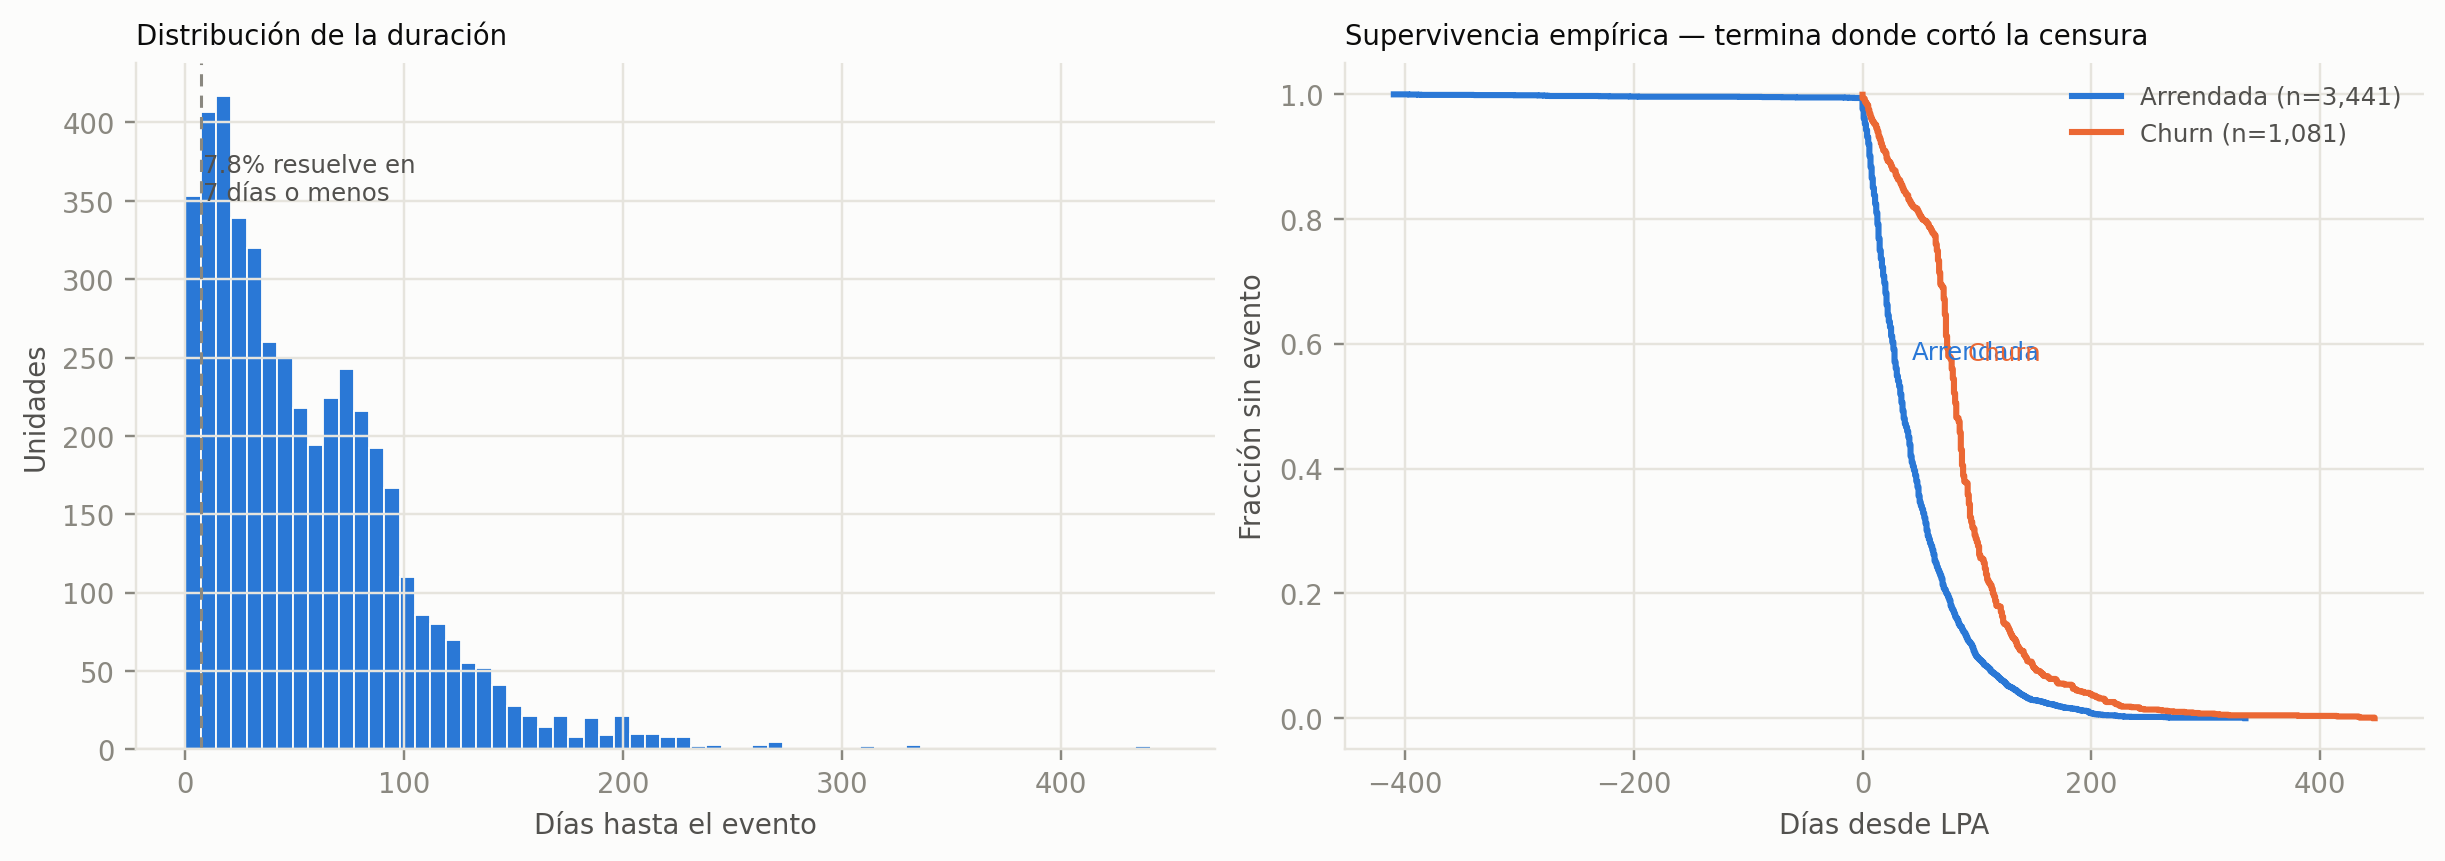

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

ax = axes[0]
bins = np.arange(0, dataframe["days_to_event"].max() + 7, 7)
ax.hist(dataframe["days_to_event"], bins=bins, color=AZUL, edgecolor=SURFACE, linewidth=0.6)
pico = (dataframe["days_to_event"] <= 7).mean()
ax.axvline(7, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
ax.annotate(f"{pico:.1%} resuelve en\n7 días o menos",
            xy=(8, ax.get_ylim()[1] * 0.80), color=INK_SOFT, fontsize=8)
ax.set_xlabel("Días hasta el evento"); ax.set_ylabel("Unidades")
ax.set_title("Distribución de la duración", fontsize=9, loc="left")

ax = axes[1]
for cv, color, etq in [(0, AZUL, "Arrendada"), (1, NARANJA, "Churn")]:
    s = np.sort(dataframe.loc[dataframe["churn"] == cv, "days_to_event"].dropna().values)
    if not len(s):
        continue
    surv = 1 - np.arange(1, len(s) + 1) / len(s)
    ax.step(s, surv, where="post", color=color, lw=2, label=f"{etq} (n={len(s):,})")
    k = int(len(s) * 0.45)
    ax.annotate(etq, xy=(s[k], surv[k]), xytext=(5, 5), textcoords="offset points",
                color=color, fontsize=8)
ax.set_xlabel("Días desde LPA"); ax.set_ylabel("Fracción sin evento")
ax.set_title("Supervivencia empírica — termina donde cortó la censura",
             fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT)
plt.show()

## Paso 3 · Nivel de precio por sector — contexto, no test

Small multiples en vez de color por sector: con siete categorías en un scatter el color no
distingue, y facetar además separa el confounding. Eje log porque un puñado de outliers
comprime el resto de los datos.

Esta figura sirve para ver rangos y detectar contaminación. **No** puede mostrar el efecto
de pricing, y el título lo dice explícitamente para que nadie la lea mal en una presentación.

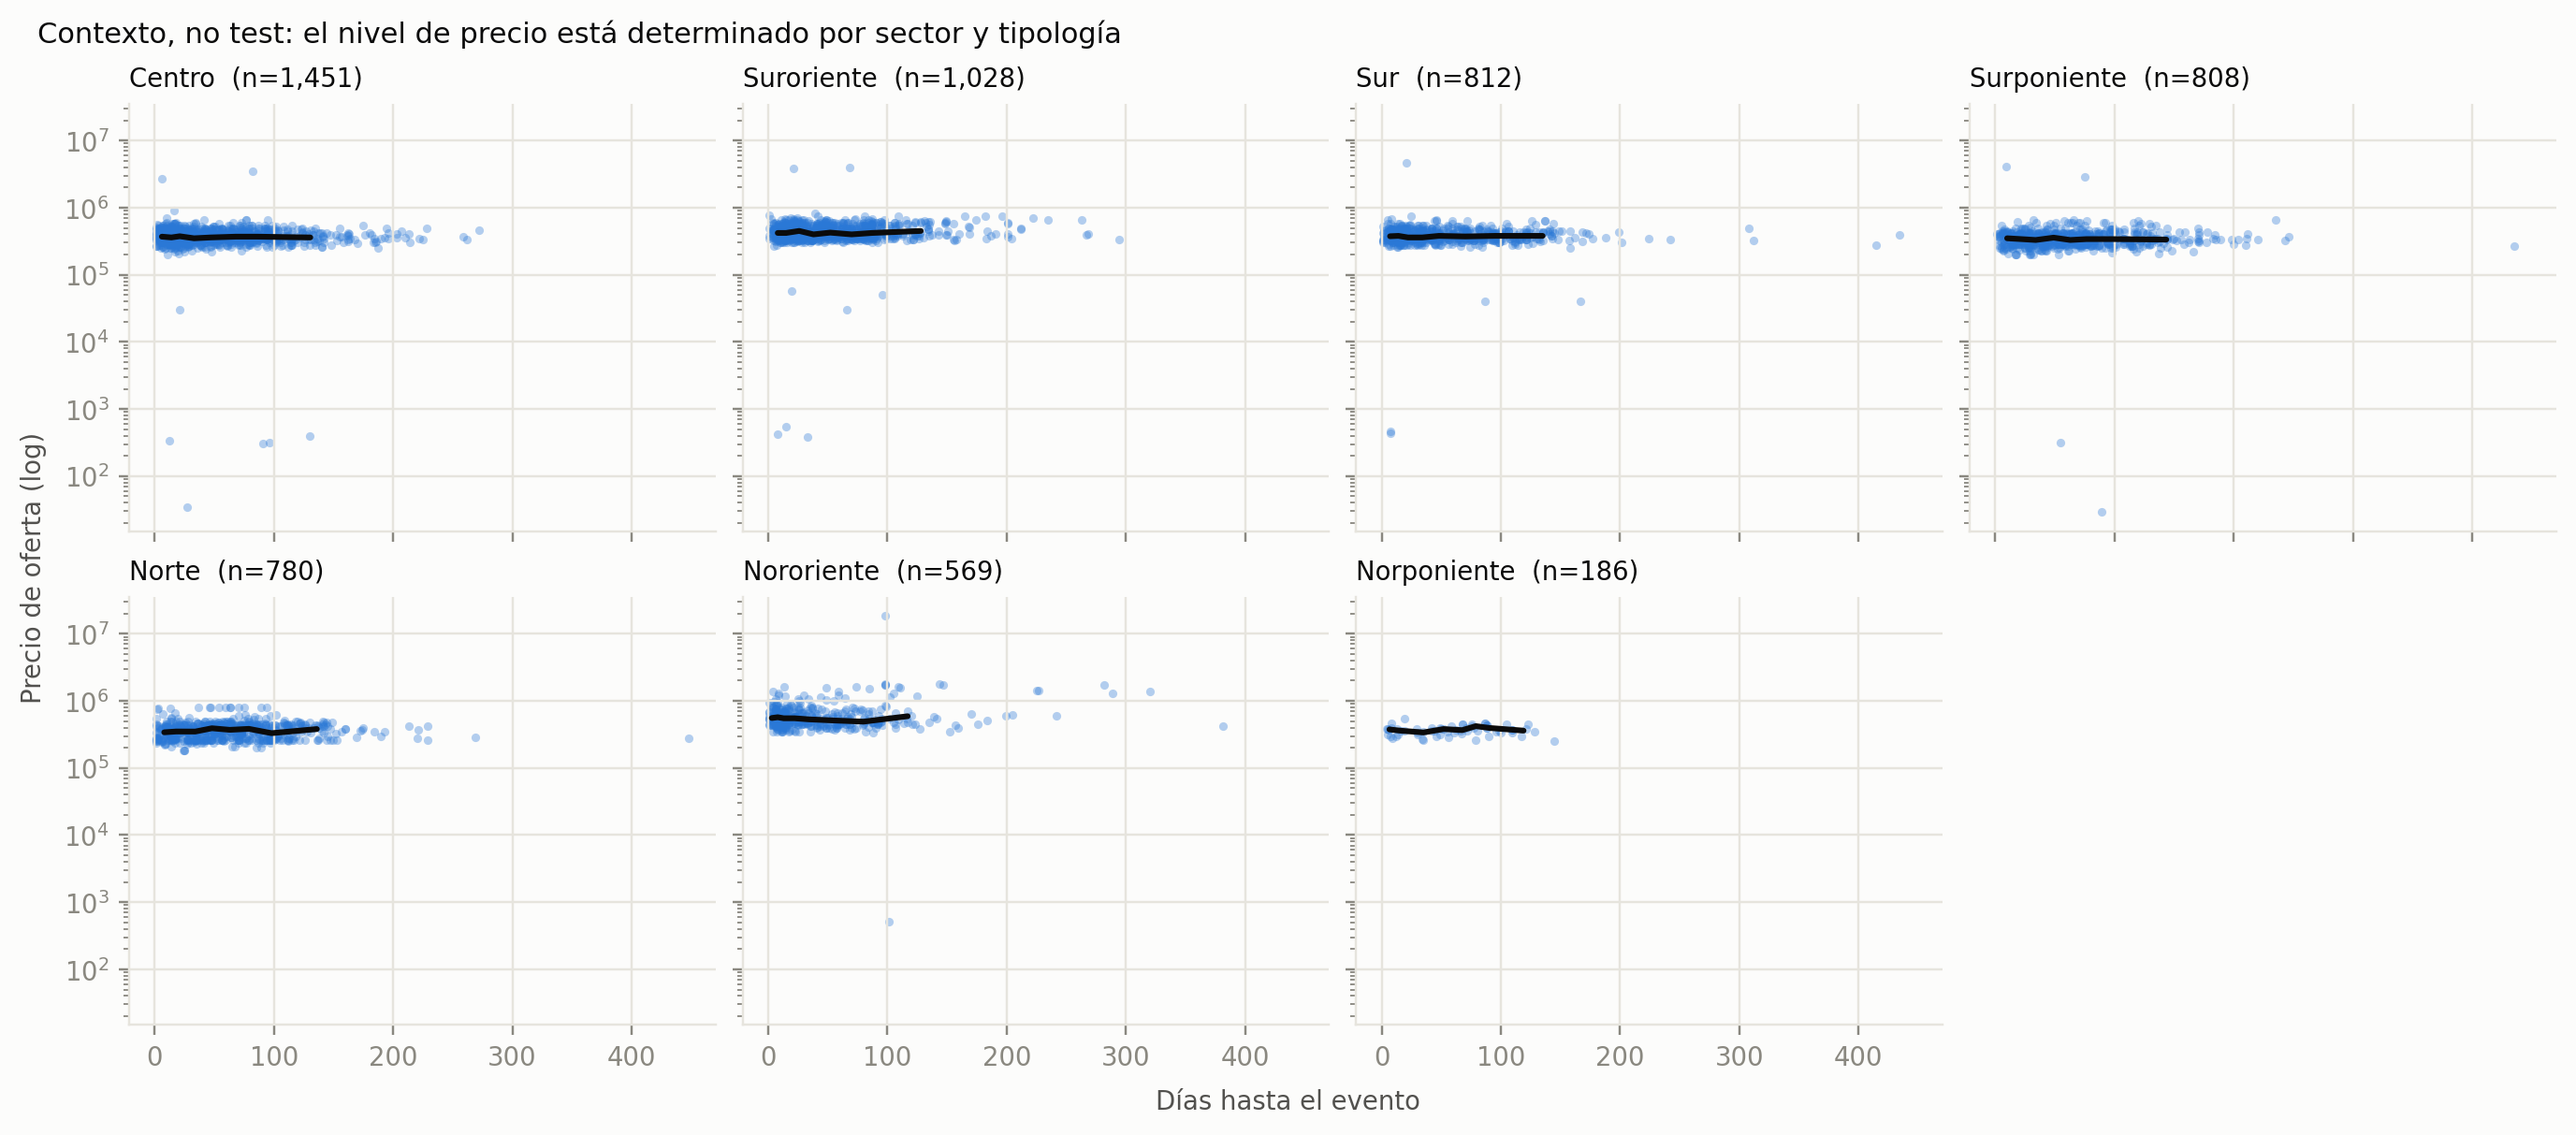

In [10]:
sectores = dataframe["sector_provincia"].value_counts().index.tolist()
ncol = 4
nrow = int(np.ceil(len(sectores) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.7 * nrow),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, sec in zip(axes, sectores):
    g = dataframe[dataframe["sector_provincia"] == sec]
    ax.scatter(g["days_to_event"], g["precio_oferta"], s=9, alpha=0.35,
               color=AZUL, linewidths=0)
    b = mediana_por_bin(g["days_to_event"].values, g["precio_oferta"].values, n_bins=8)
    if len(b):
        ax.plot(b["x"], b["p50"], color=INK, lw=2, solid_capstyle="round")
    ax.set_yscale("log")
    ax.set_title(f"{sec.replace('Santiago - ', '')}  (n={len(g):,})", fontsize=9, loc="left")
for ax in axes[len(sectores):]:
    ax.set_visible(False)

fig.supxlabel("Días hasta el evento", color=INK_SOFT, fontsize=9)
fig.supylabel("Precio de oferta (log)", color=INK_SOFT, fontsize=9)
fig.suptitle("Contexto, no test: el nivel de precio está determinado por sector y tipología",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

## Paso 4 · El test

`log_ratio_centrado` en el eje X — el gap contra el ML, centrado en su celda
comuna × tipología × mes. El centrado absorbe la deriva de mercado que introduce el snapshot
ex-post del ML, y el confounding de segmento que hacía ilegible el gráfico original.

Tres paneles porque son tres preguntas distintas:

- **Arrendadas** — ¿el sobreprecio alarga la colocación? La mediana debería subir.
- **Churneadas** — la misma pendiente aquí, pero con signo contrario, es la cancelación.
- **Churn** — ¿el sobreprecio no demora sino que mata? Este panel es la otra mitad.

In [ ]:
desempleo_total = pd.read_excel('desempleo_nacional.xlsx')
desempleo_20_24 = pd.read_excel('desempleo_20_24.xlsx')
desempleo_25_29 = pd.read_excel('desempleo_25_29.xlsx')
desempleo_30_34 = pd.read_excel('desempleo_30_34.xlsx')

#desempleo total
desempleo_total['tasa_des_tot'] = desempleo_total['fuerza de trabajo total'] - desempleo_total['personas desocupadas total']

#desempleo grupo 20 a 24 años
desempleo_20_24['tasa_des_20a24_h'] = desempleo_20_24['fuerza de trabajo hombres'] - desempleo_20_24['desocupados hombres']
desempleo_20_24['tasa_des_20a24_m'] = desempleo_20_24['fuerza de trabajo mujeres'] - desempleo_20_24['desocupados  mujeres']

#desempleo grupo 25 a 29 años
desempleo_25_29['tasa_des_25a29_h'] = desempleo_25_29['fuerza de trabajo hombres'] - desempleo_25_29['desocupados hombres']
desempleo_25_29['tasa_des_25a29_m'] = desempleo_25_29['fuerza de trabajo mujeres'] - desempleo_25_29['desocupados  mujeres']

#desempleo grupo 30 a 34 años
desempleo_30_34['tasa_des_30a34_h'] = desempleo_30_34['fuerza de trabajo hombres'] - desempleo_30_34['desocupados hombres']
desempleo_30_34['tasa_des_30a34_m'] = desempleo_30_34['fuerza de trabajo mujeres'] - desempleo_30_34['desocupados  mujeres']

#Data desempleo
desempleo = [desempleo_total['Periodo'], desempleo_total['tasa_des_tot'], desempleo_20_24['tasa_des_20a24_h'], desempleo_20_24['tasa_des_20a24_m'], desempleo_25_29['tasa_des_25a29_h'], desempleo_25_29['tasa_des_25a29_m'], desempleo_30_34['tasa_des_30a34_h'], desempleo_30_34['tasa_des_30a34_h']]


,Periodo,1.1. Fuerza de trabajo mujeres,1.1.2. Desocupadas mujeres,2.1. Fuerza de trabajo hombres,2.1.2. Desocupados hombres
0,2010-03-01,322.614137,67.695353,471.661516,84.645802
1,2010-04-01,330.480558,67.159394,469.177833,75.254753
2,2010-05-01,329.108419,65.049356,466.783113,79.310661
3,2010-06-01,326.412682,60.856568,470.571977,73.562091
4,2010-07-01,323.689227,55.096928,465.957257,74.247048
...,...,...,...,...,...
191,2026-02-01,279.747377,62.874107,360.388458,63.423808
192,2026-03-01,280.062355,67.657000,351.081812,64.447855
193,2026-04-01,272.628843,69.646358,338.681264,56.904358
194,2026-05-01,273.362817,68.782883,332.897786,66.380452


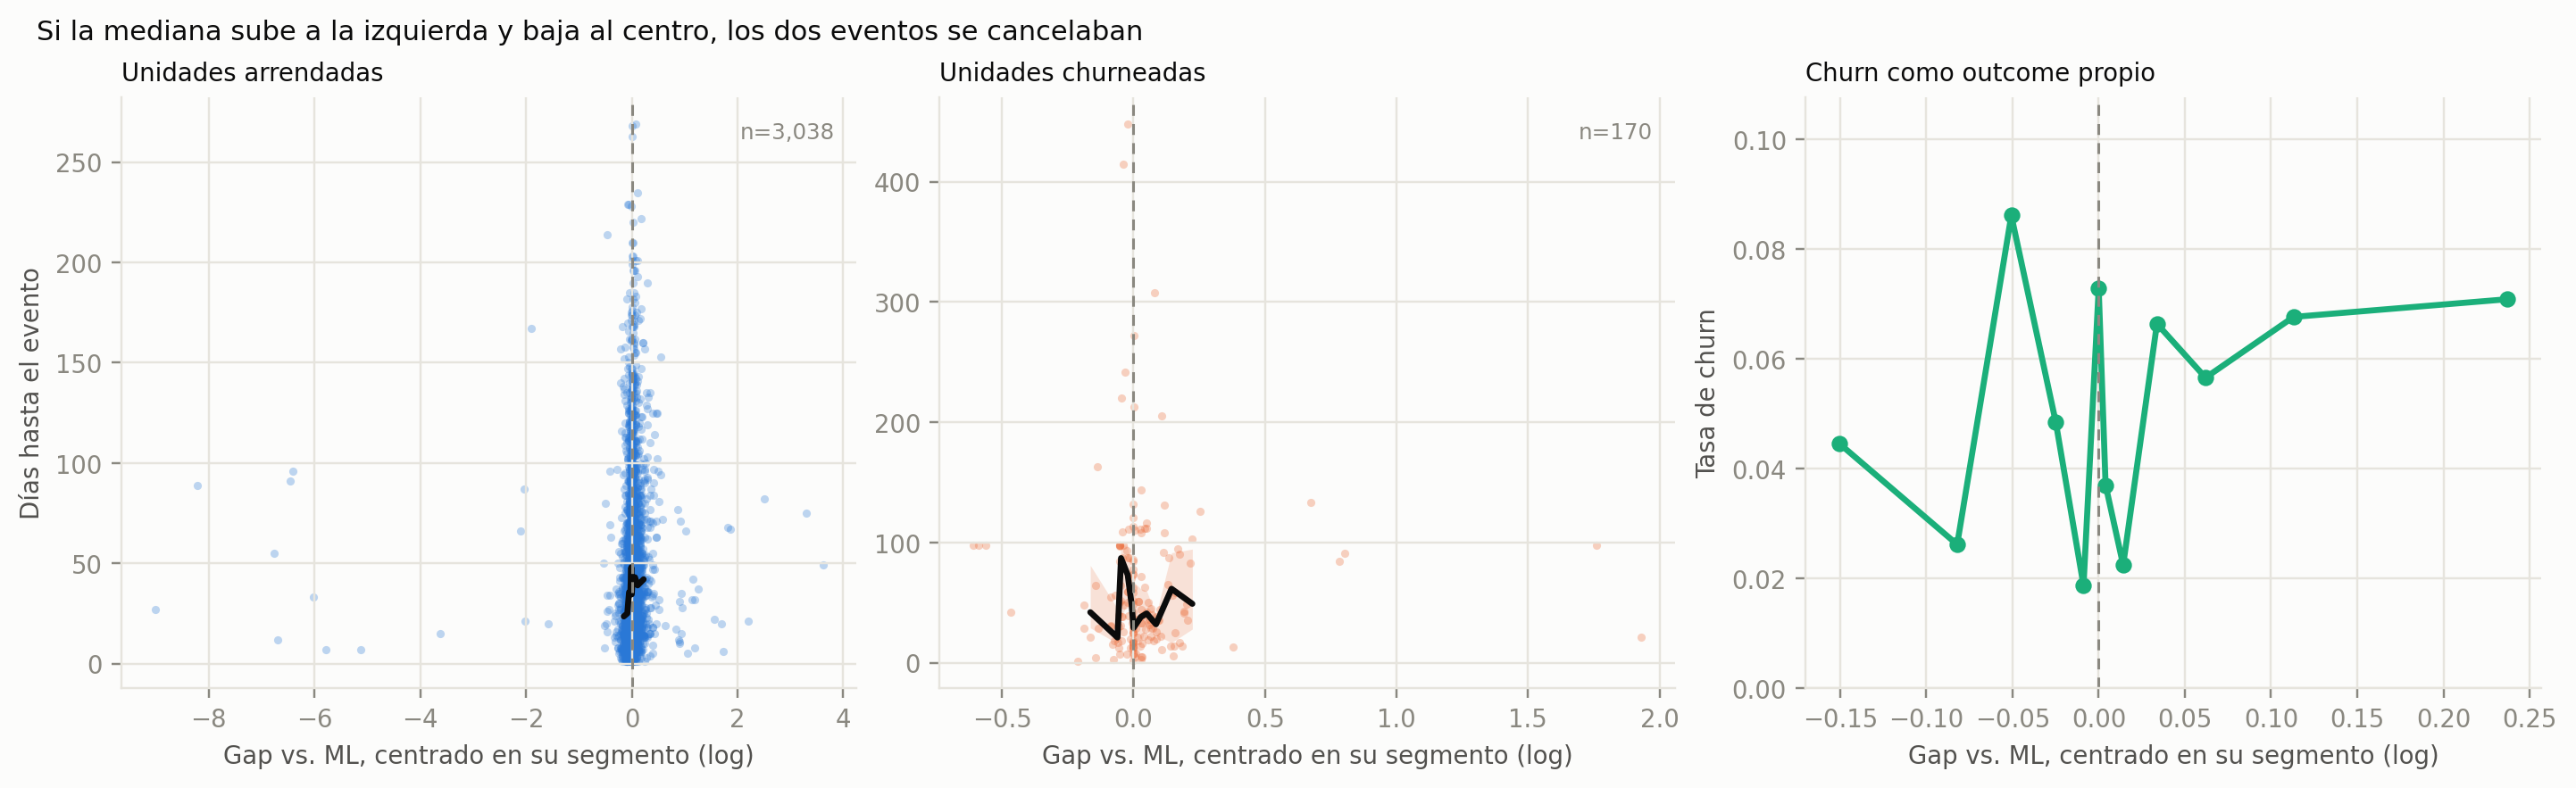

In [11]:
GAP = "log_ratio_centrado"   # cambiar a "log_ratio_ml" para ver el gap sin centrar

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), constrained_layout=True)

for ax, (cv, titulo, color) in zip(
    axes[:2], [(0, "Unidades arrendadas", AZUL), (1, "Unidades churneadas", NARANJA)]
):
    g = dataframe[(dataframe["churn"] == cv) & dataframe[GAP].notna()]
    ax.scatter(g[GAP], g["days_to_event"], s=9, alpha=0.30, color=color, linewidths=0)
    b = mediana_por_bin(g[GAP].values, g["days_to_event"].values)
    if len(b):
        ax.fill_between(b["x"], b["p25"], b["p75"], color=color, alpha=0.18, linewidth=0)
        ax.plot(b["x"], b["p50"], color=INK, lw=2.2, solid_capstyle="round")
        ax.annotate(f"n={int(b['n'].sum()):,}", xy=(0.97, 0.93), xycoords="axes fraction",
                    ha="right", color=INK_MUTED, fontsize=8)
    ax.axvline(0, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
    ax.set_title(titulo, fontsize=9, loc="left")
    ax.set_xlabel("Gap vs. ML, centrado en su segmento (log)")
axes[0].set_ylabel("Días hasta el evento")

ax = axes[2]
g = dataframe[dataframe[GAP].notna()]
b = mediana_por_bin(g[GAP].values, g["churn"].values)
tasa = (g.assign(_bin=pd.qcut(g[GAP], 12, duplicates="drop"))
         .groupby("_bin", observed=True)
         .agg(gap=(GAP, "median"), churn=("churn", "mean"), n=("churn", "size"))
         .query("n >= 5"))
ax.plot(tasa["gap"], tasa["churn"], color=AQUA, lw=2.2, marker="o", ms=5,
        solid_capstyle="round")
ax.axvline(0, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
ax.set_ylim(0, tasa["churn"].max() * 1.25)
ax.set_xlabel("Gap vs. ML, centrado en su segmento (log)")
ax.set_ylabel("Tasa de churn")
ax.set_title("Churn como outcome propio", fontsize=9, loc="left")

fig.suptitle("Si la mediana sube a la izquierda y baja al centro, los dos eventos se cancelaban",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

## Paso 5 · El mismo test en números

Para pegar en un informe. `dias_p50` solo entre arrendadas; `tasa_churn` sobre el total del decil.

In [12]:
tabla = (dataframe[dataframe[GAP].notna()]
         .assign(decil=lambda t: pd.qcut(t[GAP], 10, labels=False, duplicates="drop") + 1)
         .groupby("decil")
         .apply(lambda g: pd.Series({
             "n":              len(g),
             "gap_medio":      g[GAP].mean(),
             "gap_pct":        np.expm1(g[GAP].mean()),
             "dias_p50":       g.loc[g["churn"] == 0, "days_to_event"].median(),
             "tasa_churn":     g["churn"].mean(),
             "visitas_2sem":   g[["visitas_sem_1", "visitas_sem_2"]].sum(axis=1).mean(),
             "leads":          g["leads"].mean(),
             "reservas":       g["reservas"].mean(),
         }), include_groups=False)
         .round(3))
tabla

,n,gap_medio,gap_pct,dias_p50,tasa_churn,visitas_2sem,leads,reservas
decil,,,,,,,,
1,321.0,-0.392,-0.325,24.0,0.037,20.542,9.875,0.835
2,325.0,-0.072,-0.069,25.0,0.043,12.929,5.963,0.846
3,317.0,-0.039,-0.038,38.0,0.069,12.379,9.577,0.852
4,334.0,-0.013,-0.013,47.0,0.033,8.590,5.850,0.847
5,439.0,-0.001,-0.001,33.0,0.068,19.686,10.704,0.850
6,189.0,0.005,0.005,45.5,0.037,7.889,5.228,0.783
7,322.0,0.021,0.021,42.0,0.047,8.342,5.919,0.758
8,319.0,0.047,0.048,41.0,0.053,10.013,7.038,0.840
9,321.0,0.098,0.103,42.0,0.059,10.885,7.458,0.832


## Cómo leer el conjunto

| Lo que ves | Lo que significa |
|---|---|
| `sd` del gap bajo 0,05 | El ML aprendió la política de precios de la casa, no el mercado. No hay varianza que correlacionar y el problema está en el target de entrenamiento. |
| Gradiente en arrendadas, invertido en churn | Los dos eventos se cancelaban dentro de `days_to_event`. La correlación existía. |
| Gradiente **solo** en la tasa de churn | El sobreprecio no alarga la colocación: la mata. La unidad no espera más, sale del inventario. Hallazgo distinto y comercialmente más relevante. |
| Deciles centrales planos, extremos que se mueven | Efecto de umbral. Usar dummies por tramo, nunca una pendiente lineal. |
| Visitas planas entre deciles | La señal de precio no está llegando al mercado. Revisar publicación en portales y promociones no registradas. |
| Pico grande en la primera semana | `fecha_LPA` retroalimentada. Hay que resolverlo antes de interpretar cualquier duración. |

**Una advertencia que no se arregla con datos.** Si el precio se fija a partir de la
recomendación del ML, las desviaciones no son ruido aleatorio: son información privada del
equipo comercial sobre la unidad (vista, ruido, terminaciones). El gap entonces mide en parte
calidad no observada por el modelo, y eso empuja la correlación hacia cero. Nada de lo que hay
en este notebook lo resuelve — se necesita variación exógena, tipo un A/B de precios. Lo que
sale de acá es asociación, y conviene presentarlo como tal.